In [4]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy

In [26]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [ ]:
# Load best-fit models and data

u = 1.3e-8

graph_Bherer_0 = "best_fit_models/null_human_neanderthal_Bherer.yaml"
graph_ZhouJHS_0 = "best_fit_models/null_human_neanderthal_ZhouJHS.yaml"
graph_ZhouFHS_0 = "best_fit_models/null_human_neanderthal_ZhouFHS.yaml"
params_0 = "models/null_human_neanderthal_params.yaml"

graph_Bherer_1 = "best_fit_models/human_neanderthal_pulse_Bherer.yaml"
graph_ZhouJHS_1 = "best_fit_models/human_neanderthal_pulse_ZhouJHS.yaml"
graph_ZhouFHS_1 = "best_fit_models/human_neanderthal_pulse_ZhouFHS.yaml"
params_1 = "models/human_neanderthal_pulse_params.yaml"

fdata_Bherer = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"
fdata_ZhouJHS = "../../analyses/recombination_maps/stats/subset_ZhouJHS.pkl"
fdata_ZhouFHS = "../../analyses/recombination_maps/stats/subset_ZhouFHS.pkl"

data_Bherer = dpluspy.inference.load_bootstrap_reps(
    fdata_Bherer, graph=graph_Bherer_0, return_dict=True)
data_ZhouJHS = dpluspy.inference.load_bootstrap_reps(
    fdata_ZhouJHS, graph=graph_Bherer_0, return_dict=True)
data_ZhouFHS = dpluspy.inference.load_bootstrap_reps(
    fdata_ZhouFHS, graph=graph_Bherer_0, return_dict=True)

model_Bherer_0 = dpluspy.inference.compute_bin_stats(graph_Bherer_0, 
    sampled_demes=data_Bherer["pop_ids"], bins=data_Bherer["bins"], u=u)
model_ZhouJHS_0 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_0, 
    sampled_demes=data_ZhouJHS["pop_ids"], bins=data_ZhouJHS["bins"], u=u)
model_ZhouFHS_0 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_0, 
    sampled_demes=data_ZhouFHS["pop_ids"], bins=data_ZhouFHS["bins"], u=u)

model_Bherer_1 = dpluspy.inference.compute_bin_stats(graph_Bherer_1, 
    sampled_demes=data_Bherer["pop_ids"], bins=data_Bherer["bins"], u=u)
model_ZhouJHS_1 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_1, 
    sampled_demes=data_ZhouJHS["pop_ids"], bins=data_ZhouJHS["bins"], u=u)
model_ZhouFHS_1 = dpluspy.inference.compute_bin_stats(graph_ZhouJHS_1, 
    sampled_demes=data_ZhouFHS["pop_ids"], bins=data_ZhouFHS["bins"], u=u)

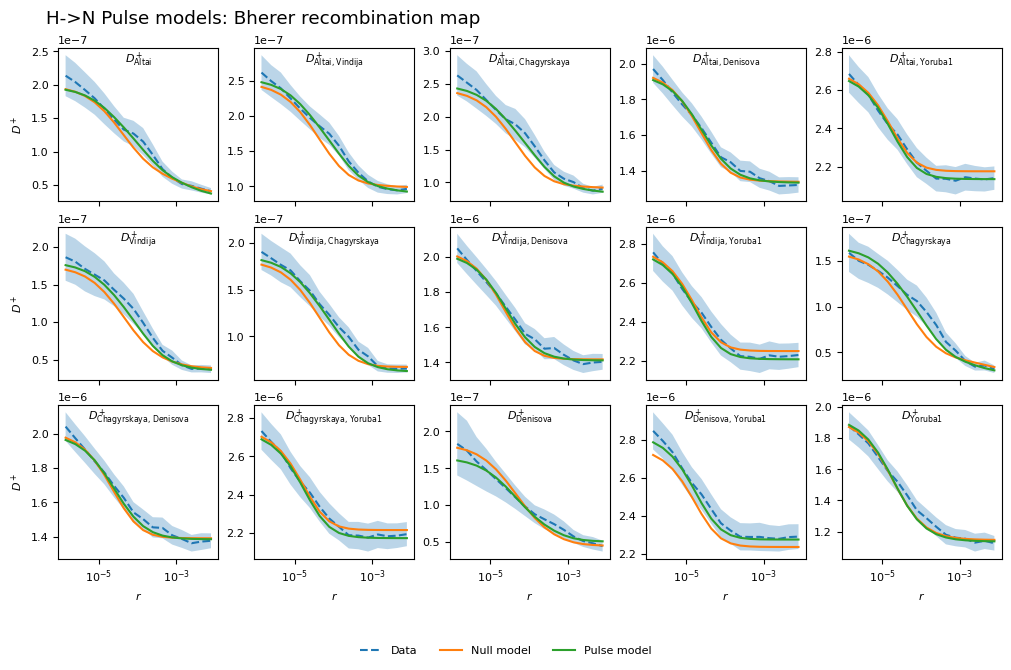

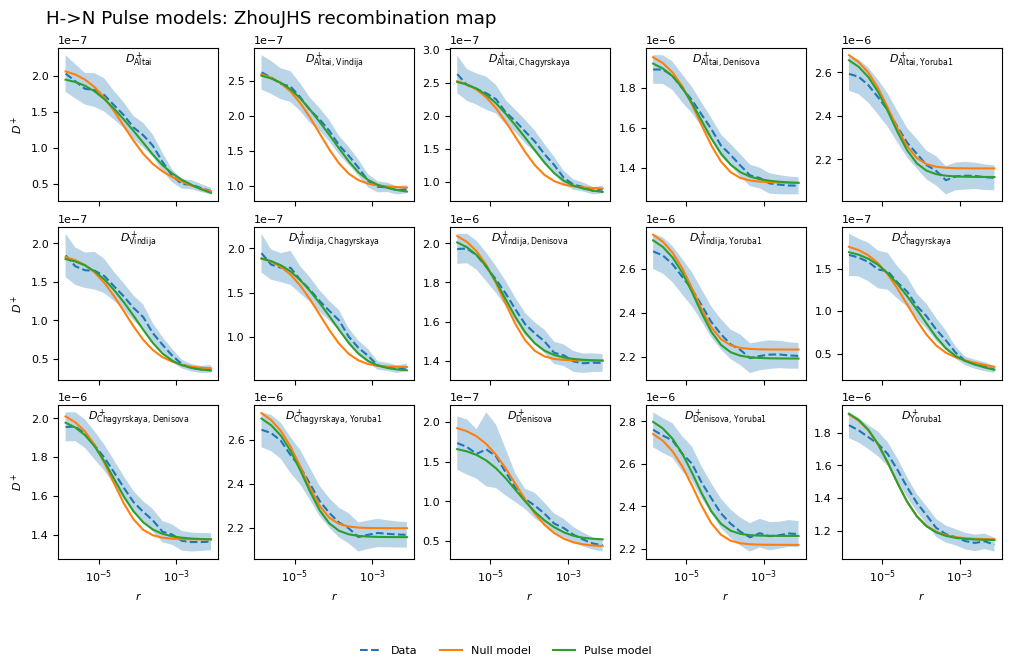

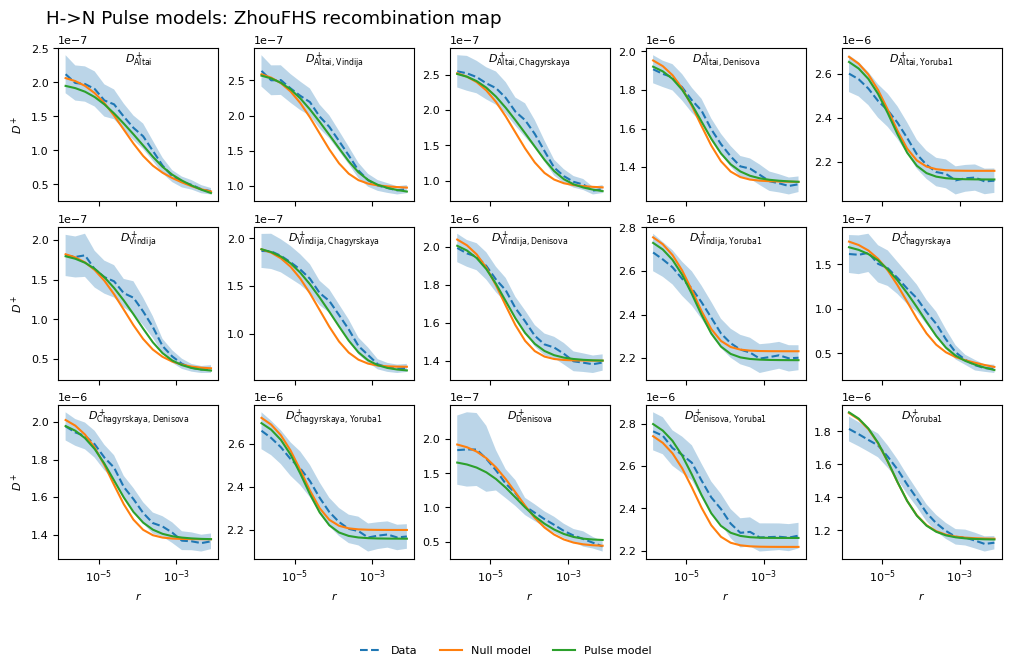

In [50]:
# Plot best-fit models

dpluspy.plotting.plot_D_plus_curves(
    models=[model_Bherer_0, model_Bherer_1],
    pop_ids=data_Bherer["pop_ids"], 
    bins=data_Bherer["bins"], 
    means=data_Bherer["means"], 
    varcovs=data_Bherer["varcovs"], 
    labels=["Data", "Null model", "Pulse model"],
    title="H->N Pulse models: Bherer recombination map",
    out="figures/Bherer_best_fit_models.pdf"
)


dpluspy.plotting.plot_D_plus_curves(
    models=[model_ZhouJHS_0, model_ZhouJHS_1],
    pop_ids=data_ZhouJHS["pop_ids"], 
    bins=data_ZhouJHS["bins"], 
    means=data_ZhouJHS["means"], 
    varcovs=data_ZhouJHS["varcovs"], 
    labels=["Data", "Null model", "Pulse model"],
    title="H->N Pulse models: ZhouJHS recombination map",
    out="figures/ZhouJHS_best_fit_models.pdf"
)


dpluspy.plotting.plot_D_plus_curves(
    models=[model_ZhouFHS_0, model_ZhouFHS_1],
    pop_ids=data_ZhouFHS["pop_ids"], 
    bins=data_ZhouFHS["bins"], 
    means=data_ZhouFHS["means"], 
    varcovs=data_ZhouFHS["varcovs"], 
    labels=["Data", "Null model", "Pulse model"],
    title="H->N Pulse models: ZhouFHS recombination map",
    out="figures/ZhouFHS_best_fit_models.pdf"
)

In [31]:
# Bootstrap LRT

# First load and aggregate bootstrap-rep fits

model_0 = "null_human_neanderthal"
model_1 = "human_neanderthal_pulse"
datasets = ["Bherer", "ZhouFHS", "ZhouJHS"]
num_reps = 100

for dataset in datasets:
    results_0 = []
    results_1 = []
    for rep in range(num_reps):
        fname_0 = f"model_choice/bootstrap_fits/{model_0}_{dataset}_rep{rep}.csv"
        fname_1 = f"model_choice/bootstrap_fits/{model_1}_{dataset}_rep{rep}.csv"
        try:
            result_0 = pandas.read_csv(fname_0)
            result_1 = pandas.read_csv(fname_1)
            results_0.append(result_0)
            results_1.append(result_1)
        except:
            print(f"Missing file {fname_0} or {fname_1}")
    out_fname_0 = f"model_choice/{model_0}_{dataset}_reps.csv"
    out_fname_1 = f"model_choice/{model_1}_{dataset}_reps.csv"
    pandas.concat(results_0).to_csv(out_fname_0, index=False)
    pandas.concat(results_1).to_csv(out_fname_1, index=False)

tbl_Bherer_0 = pandas.read_csv("model_choice/null_human_neanderthal_Bherer_reps.csv")
tbl_Bherer_1 = pandas.read_csv("model_choice/human_neanderthal_pulse_Bherer_reps.csv")
tbl_ZhouFHS_0 = pandas.read_csv("model_choice/null_human_neanderthal_ZhouFHS_reps.csv")
tbl_ZhouFHS_1 = pandas.read_csv("model_choice/human_neanderthal_pulse_ZhouFHS_reps.csv")
tbl_ZhouJHS_0 = pandas.read_csv("model_choice/null_human_neanderthal_ZhouJHS_reps.csv")
tbl_ZhouJHS_1 = pandas.read_csv("model_choice/human_neanderthal_pulse_ZhouJHS_reps.csv")

Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep30.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep30.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep33.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep33.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep34.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep34.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep40.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep40.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep47.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep47.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep57.csv or model_choice/bootstrap_fits/human_neanderthal_pulse_Bherer_rep57.csv
Missing file model_choice/bootstrap_fits/null_human_neanderthal_Bherer_rep76.csv o

In [12]:
# Find the naive alpha = 0.05 rejection threshold

weights = (0, 0.5, 0.5)
thresh = 5.1384
print(moments.Godambe.sum_chi2_ppf(thresh, weights))

0.04999950253982055


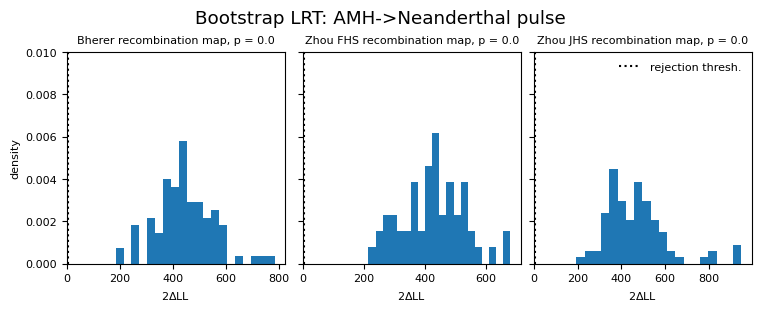

In [101]:
# Plot LRT stat distributions for three data sets

ll0 = np.array(tbl_Bherer_0["ll"])
ll1 = np.array(tbl_Bherer_1["ll"])
D_Bherer = 2 * (ll1 - ll0)
p_Bherer = 1 - np.sum(D_Bherer > thresh) / len(D_Bherer)

ll0 = np.array(tbl_ZhouFHS_0["ll"])
ll1 = np.array(tbl_ZhouFHS_1["ll"])
D_ZhouFHS = 2 * (ll1 - ll0)
p_ZhouFHS = 1 - np.sum(D_ZhouFHS > thresh) / len(D_ZhouFHS)

ll0 = np.array(tbl_ZhouJHS_0["ll"])
ll1 = np.array(tbl_ZhouJHS_1["ll"])
D_ZhouJHS = 2 * (ll1 - ll0)
p_ZhouJHS = 1 - np.sum(D_ZhouJHS > thresh) / len(D_ZhouJHS)


fig, (ax0, ax1, ax2) = plt.subplots(
    1, 3, figsize=(7.5, 3), sharey=True, layout="constrained")
fig.suptitle("Bootstrap LRT: AMH->Neanderthal pulse")


ax0.set_ylim(0, 0.01)
ax0.hist(D_Bherer, bins=20, color="tab:blue", density=True)
ax0.vlines(thresh, 0, 1, transform=ax0.get_xaxis_transform(),
    color="black", linestyles="dotted", label="rejection thresh.")
ax0.set_title(f"Bherer recombination map, p = {p_Bherer:.5}")
ax0.set_xlabel(r"$2\Delta \text{LL}$")
ax0.set_ylabel("density")
ax0.set_xlim(0, )

ax1.hist(D_ZhouFHS, bins=20, color="tab:blue", density=True)
ax1.vlines(thresh, 0, 1, transform=ax1.get_xaxis_transform(),
    color="black", linestyles="dotted", label="rejection thresh.")
ax1.set_title(f"Zhou FHS recombination map, p = {p_ZhouFHS:.5}")
ax1.set_xlabel(r"$2\Delta \text{LL}$")
ax1.set_xlim(0, )

ax2.hist(D_ZhouJHS, bins=20, color="tab:blue", density=True)
ax2.vlines(thresh, 0, 1, transform=ax2.get_xaxis_transform(),
    color="black", linestyles="dotted", label="rejection thresh.")
ax2.set_title(f"Zhou JHS recombination map, p = {p_ZhouJHS:.5}")
ax2.set_xlabel(r"$2\Delta \text{LL}$")
ax2.legend(framealpha=0)
ax2.set_xlim(0, )

plt.savefig("figures/bootstrap_LRT_distributions.png", dpi=244)

In [57]:
# Build a table of best-fit model parameters

model_0 = "null_human_neanderthal"
model_1 = "human_neanderthal_pulse"
datasets = ["Bherer", "ZhouFHS", "ZhouJHS"]
dfs = []

for dataset in datasets:
    for i, model in enumerate([model_0, model_1]):
        param_file = f"models/{model}_params.yaml"
        graph_file = f"best_fit_models/{model}_{dataset}.yaml"
        pnames, pvals = dpluspy.inference._load_params(graph_file, param_file)
        pdict = {"model": f"{i}_{dataset}"}
        pdict.update({pname: [pval] for pname, pval in zip(pnames, pvals)})
        dfs.append(pandas.DataFrame(pdict))

mle_df = pandas.concat(dfs)
print(mle_df)

       model          T_NDH           T_ND        T_AltWN      T_ChaVin  \
0   0_Bherer  784452.870120  567477.876910  133771.897098  84416.655986   
0   1_Bherer  778635.316502  721464.945308  126345.740363  86834.697209   
0  0_ZhouFHS  773947.316835  528136.892392  132243.964065  86139.050729   
0  1_ZhouFHS  742773.301514  726980.372122  125347.418206  87140.780903   
0  0_ZhouJHS  740775.347957  508898.029180  130553.483176  85920.619589   
0  1_ZhouJHS  750383.038180  727710.078705  121429.015738  85281.457508   

          N_Anc         N_Yor          N_ND        N_Den          N_N  \
0  15812.823031  28452.352680  10751.330417  3107.974284  3609.907632   
0  16169.102003  27362.541339   2173.586719  3696.206306  2929.326584   
0  15864.914022  28490.868412  12719.833380  2970.213803  3388.319812   
0  16637.654186  26840.143618    614.916412  3790.448621  2779.849211   
0  16451.673083  27685.265108  12058.911228  2868.964486  3301.184932   
0  16568.397350  27089.042367    872

In [52]:
# Get bootstrap confidence intervals
dfs = []

for dataset in datasets:
    for i, model in enumerate([model_0, model_1]):
        bootstrap_tbl = pandas.read_csv(f"model_choice/{model}_{dataset}_reps.csv")
        param_arr = np.array(bootstrap_tbl)[:, 1:]
        uncerts = np.std(param_arr, axis=0)
        udict = {"model": f"{i}_{dataset}"}
        udict.update({pname: [u] for pname, u in zip(pnames, uncerts)})
        dfs.append(pandas.DataFrame(udict))

boot_ci_df = pandas.concat(dfs)
boot_ci_df.to_csv("bootstrap_uncerts.csv")
print(boot_ci_df)

       model         T_NDH          T_ND      T_AltWN     T_ChaVin  \
0   0_Bherer  26425.637505  20259.411182  4236.980061  1739.253794   
0   1_Bherer  22649.718375  22143.960356  6257.362144  5461.366553   
0  0_ZhouFHS  20281.002971  23236.085189  3572.147574  1823.194221   
0  1_ZhouFHS  32763.827348  33111.366474  3789.741141  3138.269843   
0  0_ZhouJHS  20107.230621  21152.242974  4050.687592  1875.003727   
0  1_ZhouJHS  24338.987763  24432.139521  3311.021895  2699.118677   

        N_Anc        N_Yor         N_ND       N_Den         N_N       N_Alt  \
0  450.742433   840.759906  1760.171818  143.320515   97.896723  218.884331   
0  377.502100   852.535305   483.588680  163.728773  127.894387  272.426266   
0  324.412151   736.429215  1682.143928  128.482353  122.241959  189.951557   
0  533.171399  1084.018938    89.636500  141.243294  109.033892  187.767539   
0  336.533613   744.408382  1564.569693  130.353332  113.515139  178.538378   
0  409.296580   757.178832   414.99

In [54]:
# Get GIM confidence intervals: this is time-consuming

dfs = []

for dataset in datasets:
    for i, model in enumerate([model_0, model_1]):
        param_file = f"models/{model}_params.yaml"
        graph_file = f"best_fit_models/{model}_{dataset}.yaml"

        if dataset == "Bherer":
            data = data_Bherer
        elif dataset == "ZhouFHS":
            data = data_ZhouFHS
        elif dataset == "ZhouJHS":
            data = data_ZhouJHS

        bins = data["bins"]
        means = data["means"]
        varcovs = data["varcovs"]
        pop_ids = data["pop_ids"]
        bootreps = data["replicates"]

        pnames, _, uncerts = dpluspy.uncerts.GIM_uncerts(
            graph_file,
            param_file,
            means, 
            varcovs,
            pop_ids=pop_ids,
            bins=bins,
            u=1.3e-8,
            bootreps=bootreps,
        )

        udict = {"model": f"{i}_{dataset}"}
        udict.update({pname: [u] for pname, u in zip(pnames, uncerts)})
        dfs.append(pandas.DataFrame(udict))

gim_ci_df = pandas.concat(dfs)
gim_ci_df.to_csv("GIM_uncerts.csv")
print(gim_ci_df)

[29-07-25 09:30:38] Evaluated Hessian element (0, 0)
[29-07-25 09:30:38] Evaluated Hessian element (0, 1)
[29-07-25 09:30:38] Evaluated Hessian element (0, 2)
[29-07-25 09:30:38] Evaluated Hessian element (0, 3)
[29-07-25 09:30:38] Evaluated Hessian element (0, 4)
[29-07-25 09:30:38] Evaluated Hessian element (0, 5)
[29-07-25 09:30:38] Evaluated Hessian element (0, 6)
[29-07-25 09:30:38] Evaluated Hessian element (0, 7)
[29-07-25 09:30:38] Evaluated Hessian element (0, 8)
[29-07-25 09:30:38] Evaluated Hessian element (0, 9)
[29-07-25 09:30:38] Evaluated Hessian element (0, 10)
[29-07-25 09:30:38] Evaluated Hessian element (0, 11)
[29-07-25 09:30:38] Evaluated Hessian element (0, 12)
[29-07-25 09:30:38] Evaluated Hessian element (1, 1)
[29-07-25 09:30:38] Evaluated Hessian element (1, 2)
[29-07-25 09:30:38] Evaluated Hessian element (1, 3)
[29-07-25 09:30:38] Evaluated Hessian element (1, 4)
[29-07-25 09:30:38] Evaluated Hessian element (1, 5)
[29-07-25 09:30:38] Evaluated Hessian eleme

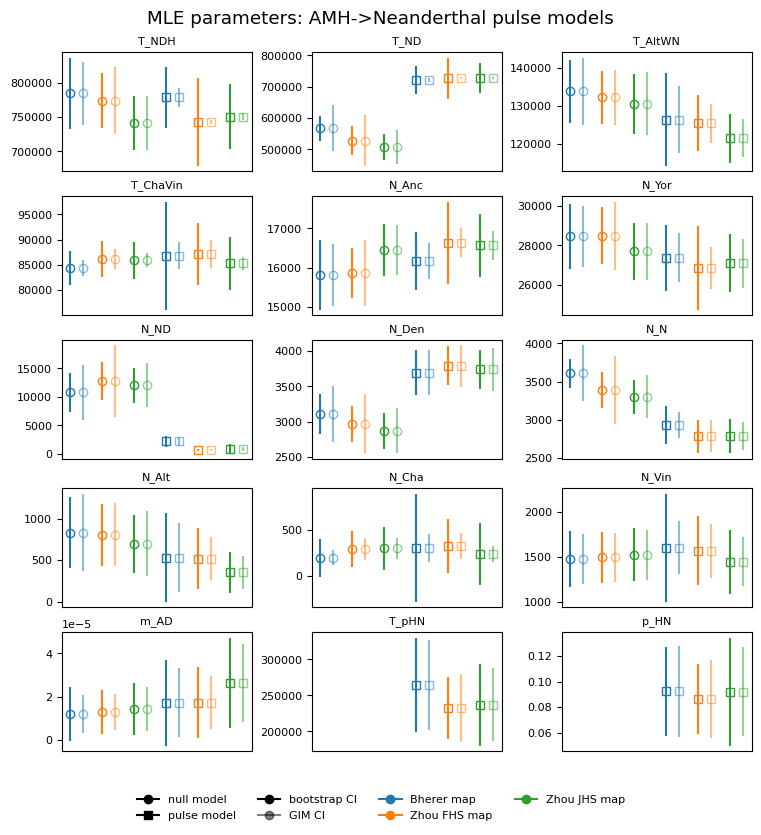

In [100]:
# Plot parameter CIs

fig, axs = plt.subplots(5, 3, figsize=(7.5, 7.5), layout="constrained", sharex=True)
axs = axs.flat

for ii, param in enumerate(mle_df.columns[1:]):
    ax = axs[ii]
    #ax.set_ylim(0, )
    ax.xaxis.set_visible(False)
    ax.set_title(param)
    ii = 0
    for model in (0, 1):
        for dataset in datasets:
            color = {"Bherer": "tab:blue", "ZhouFHS": "tab:orange", 
                     "ZhouJHS": "tab:green"}[dataset]
            marker = {0: "o", 1: "s"}[model]
            m = mle_df["model"] == f"{model}_{dataset}"
            ax.errorbar(
                [ii], 
                mle_df[m][param], 
                yerr=1.96 * boot_ci_df[m][param], 
                fmt=marker,
                color=color,
                markerfacecolor="none"
            )
            ax.errorbar(
                [ii + 0.4], 
                mle_df[m][param], 
                yerr=1.96 * gim_ci_df[m][param], 
                fmt=marker,
                color=color,
                markerfacecolor="none",
                alpha=0.5
            )
            ii += 1

from matplotlib.lines import Line2D

symbols = [
    Line2D([0], [0], color="black", marker="o"),
    Line2D([0], [0], color="black", marker="s"),
    Line2D([0], [0], color="black", marker="o", alpha=1),
    Line2D([0], [0], color="black", marker="o", alpha=0.5),
    Line2D([0], [0], color="tab:blue", marker="o"),
    Line2D([0], [0], color="tab:orange", marker="o"),
    Line2D([0], [0], color="tab:green", marker="o"),
]
handles = [
    "null model",
    "pulse model",
    "bootstrap CI",
    "GIM CI",
    "Bherer map",
    "Zhou FHS map",
    "Zhou JHS map"
]
fig.legend(symbols, handles, framealpha=0, loc="lower center", ncols=4,
    bbox_to_anchor=[0.5, -0.1])
fig.suptitle("MLE parameters: AMH->Neanderthal pulse models")

plt.savefig("figures/parameter_uncerts.png", dpi=244)

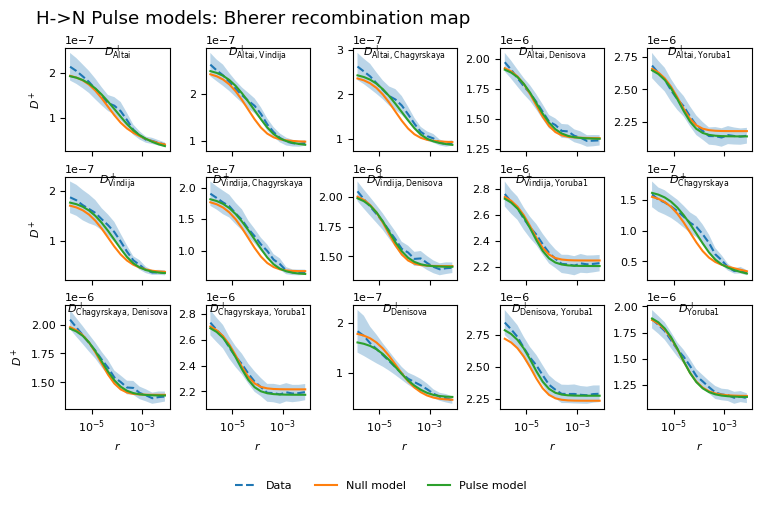

In [99]:

dpluspy.plotting.plot_D_plus_curves(
    models=[model_Bherer_0, model_Bherer_1],
    pop_ids=data_Bherer["pop_ids"], 
    bins=data_Bherer["bins"], 
    means=data_Bherer["means"], 
    varcovs=data_Bherer["varcovs"], 
    labels=["Data", "Null model", "Pulse model"],
    title="H->N Pulse models: Bherer recombination map",
    ax_size=1.5,
    out="figures/Bherer_best_fit_models_small.png"
)
